In [1]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import random
import torch
import os
import numpy as np
from model1 import CNN_3D,NiiDataset,MultiModalTransformer,NeuralNet,KGMultiModalTransformer
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

In [2]:
path_existence = []
data_normal=[]
data_ad=[]
data_mci=[]
count_ad=0
count_no=0
count_mci=0

with open('NACC_normal.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'E:/code/NACC_nii_no/NACC_nii_no/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_no=count_no+1
            data_normal.append(row)
            
with open('NACC_ad.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'E:/code/NACC_nii_ad/NACC_nii_ad/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_ad=count_ad+1
            data_ad.append(row)
            
with open('NACC_mci.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'E:/code/NACC_mci/NACC_mci/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_mci=count_mci+1
            data_mci.append(row)
print(count_ad) #713
print(count_no) #2116
print(count_mci) #879

713
2116
879


In [3]:
# 基础替换字典 (请根据NACC的具体字符继续补充)
replace_dict = {'female': '0', 'male': '1', 'whi': '0', 'blk': '1', '': '0', 'ind': '3', 'ans': '4', 'no': '0', 'yes': '1', 'haw': '3'}

# EHR 模块 (53维): 人口学 (3-7) + 病史 (60-107)
ehr_cols = [3, 4, 5, 6, 7] + list(range(60, 108))

# BIO 模块 (43维): apoe (8) + 认知量表与问卷 (18-59)
bio_cols = [8] + list(range(18, 60))

# 统一且安全的预处理函数
def preprocess_data(data, replace_dict, target_cols):
    processed_data = []
    for row in data:
        # 仅提取安全的特征列
        extracted_row = [row[idx] for idx in target_cols]
        # 字典映射替换
        extracted_row = [replace_dict.get(item, item) for item in extracted_row]
        
        numerical_row = []
        for item in extracted_row:
            try:
                val = float(item)
                # 拦截 NaN，替换为 0.0
                if math.isnan(val):
                    val = 0.0
            except ValueError:
                # 无法转换的值替换为 0.0
                val = 0.0 
            numerical_row.append(val)
            
        processed_data.append(numerical_row)
    return np.array(processed_data)

In [4]:
# 1. 提取 BIO 数组 (真实的 47 维特征)
ad_bio_array = preprocess_data(data_ad, replace_dict, bio_cols)
normal_bio_array = preprocess_data(data_normal, replace_dict, bio_cols)
mci_bio_array = preprocess_data(data_mci, replace_dict, bio_cols)

# 2. 直接转换数据为 Tensor
ad_tensor = torch.from_numpy(ad_bio_array).float()
normal_tensor = torch.from_numpy(normal_bio_array).float()
mci_tensor = torch.from_numpy(mci_bio_array).float()

# 3. 打印结果检查维度
print('AD_tensor shape:', ad_tensor.shape)       
print('Normal_tensor shape:', normal_tensor.shape) 
print('MCI_tensor shape:', mci_tensor.shape)

AD_tensor shape: torch.Size([713, 43])
Normal_tensor shape: torch.Size([2116, 43])
MCI_tensor shape: torch.Size([879, 43])


In [5]:
# 1. 提取脱敏后的 EHR 数组 (真实的 59 维特征)
ad_ehr_data = preprocess_data(data_ad, replace_dict, ehr_cols)
normal_ehr_data = preprocess_data(data_normal, replace_dict, ehr_cols)
mci_ehr_data = preprocess_data(data_mci, replace_dict, ehr_cols)

# 2. 直接转换为 Tensor
ad_EHR = torch.from_numpy(ad_ehr_data).float()
normal_EHR = torch.from_numpy(normal_ehr_data).float()
mci_EHR = torch.from_numpy(mci_ehr_data).float()

# 3. 打印结果检查维度
print('ad.EHR--->', ad_EHR.shape)
print('normal.EHR--->', normal_EHR.shape)
print('mci.EHR--->', mci_EHR.shape)

ad.EHR---> torch.Size([713, 53])
normal.EHR---> torch.Size([2116, 53])
mci.EHR---> torch.Size([879, 53])


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Using device:', device)

Using device: cuda


In [7]:
import torch
import gc
from torch.utils.data import DataLoader
from tqdm import tqdm  # 引入 tqdm 库用于显示进度

# 1. 显式清理缓存，防止之前的残留占用显存
torch.cuda.empty_cache()
gc.collect()

# 2. 实例化模型，将输出维度设为64，严格匹配 Transformer 的 img_dim=64
nii = CNN_3D(num_class=64)
nii = nii.to(device)
nii.eval() # 开启评估模式，冻结网络行为

def extract_mri_features(folder_path, batch_size=16):
    # 注意：这里将默认 batch_size 改为 4，防止 NACC 的 3D 图像导致 OOM
    dataset = NiiDataset(folder_path)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_outputs = []
    
    # 关闭梯度计算，节省显存并加快提取速度
    with torch.no_grad():
        # 使用 tqdm 包装 dataloader，实时打印当前文件夹的提取进度
        for batch_idx, batch_data in enumerate(tqdm(dataloader, desc="Extracting features")):
            batch_data = batch_data.to(device)
            output = nii(batch_data)
            # 提取后立即 detach 并转回 CPU，防止 GPU 显存堆积
            all_outputs.append(output.detach().cpu())
            
    # 每次提取完一个类别后，显式清理局部变量和显存
    del dataset, dataloader
    torch.cuda.empty_cache()
    gc.collect()
            
    return torch.cat(all_outputs, dim=0)

# NACC 图像数据路径
all_ad = 'E:/code/NACC_nii_ad/NACC_nii_ad/'
all_normal = 'E:/code/NACC_nii_no/NACC_nii_no/'
all_mci = 'E:/code/NACC_mci/NACC_mci/'

# 3. 模块化调用提取特征
ad_output = extract_mri_features(all_ad, batch_size=4)
print('ad nii shape--->', ad_output.shape)

normal_output = extract_mri_features(all_normal, batch_size=4)
print('normal nii shape--->', normal_output.shape)

mci_output = extract_mri_features(all_mci, batch_size=4)
print('mci nii shape--->', mci_output.shape)

Extracting features: 100%|██████████| 179/179 [00:27<00:00,  6.45it/s]


ad nii shape---> torch.Size([713, 64])


Extracting features: 100%|██████████| 529/529 [01:16<00:00,  6.94it/s]


normal nii shape---> torch.Size([2116, 64])


Extracting features: 100%|██████████| 220/220 [00:28<00:00,  7.59it/s]


mci nii shape---> torch.Size([879, 64])


In [ ]:
import numpy as np
import torch
import pandas as pd
import re

# 1. 指向 CustomKG 的输出文件
ENTITY_EMB_NPY = "CustomKG-NACC.npy"
ENTITY2ID_FILE = "CustomKG-NACC.txt"

# 2. 解析 TSV 格式的实体映射
entity2id = {}
with open(ENTITY2ID_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) == 2:
            entity2id[parts[0]] = int(parts[1])

# 3. 加载 CustomKG 嵌入向量
emb = torch.from_numpy(np.load(ENTITY_EMB_NPY)).float()
embed_dim = emb.shape[1]  # 此时应为 32
max_seq_len = 1 

def sanitize(text: str) -> str:
    return re.sub(r"\s+", "_", str(text).strip())

def get_patient_embedding_seq(identifier: str):
    node = sanitize(identifier)
    
    vecs = []
    pad_masks = []
    
    # 构造固定长度为1的序列与对应的布尔掩码
    for i in range(max_seq_len):
        if i == 0 and node in entity2id:
            vecs.append(emb[entity2id[node]])
            pad_masks.append(False) 
        else:
            vecs.append(torch.zeros(embed_dim))
            pad_masks.append(True) 
            
    # 返回知识序列矩阵和用于PyTorch注意力的掩码
    return torch.stack(vecs), torch.tensor(pad_masks, dtype=torch.bool)

def process_and_verify_seq(df, cohort_name):
    seq_tensors = []
    mask_tensors = []
    valid_count = 0
    
    for _, r in df.iterrows():
        # 兼容 NACC 文件的 ID 或 filename 列
        target_id = r.get('ID', r.get('filename')) 
        seq_tensor, mask_tensor = get_patient_embedding_seq(target_id)
        seq_tensors.append(seq_tensor)
        mask_tensors.append(mask_tensor)
        
        # 验证是否包含至少一个有效节点（掩码中存在False）
        if not torch.all(mask_tensor):
            valid_count += 1
            
    stacked_seq = torch.stack(seq_tensors)
    stacked_mask = torch.stack(mask_tensors)
    
    print(f"[{cohort_name}] 总样本数: {len(df)} | 成功注入KG先验序列的样本数: {valid_count}")
    return stacked_seq, stacked_mask

# 执行数据提取
print("开始提取完整知识序列与注意力掩码...")
ad_transe_seq, ad_transe_mask = process_and_verify_seq(pd.read_csv('NACC_ad.csv'), "AD")
mci_transe_seq, mci_transe_mask = process_and_verify_seq(pd.read_csv('NACC_mci.csv'), "MCI")
nc_transe_seq, nc_transe_mask = process_and_verify_seq(pd.read_csv('NACC_normal.csv'), "NC")

print("最终生成的知识序列 Shapes:", ad_transe_seq.shape, mci_transe_seq.shape, nc_transe_seq.shape)
print("最终生成的掩码张量 Shapes:", ad_transe_mask.shape, mci_transe_mask.shape, nc_transe_mask.shape)

开始提取完整知识序列与注意力掩码...
[AD] 总样本数: 713 | 成功注入KG先验序列的样本数: 709
[MCI] 总样本数: 879 | 成功注入KG先验序列的样本数: 872
[NC] 总样本数: 2116 | 成功注入KG先验序列的样本数: 1802
最终生成的知识序列 Shapes: torch.Size([713, 45, 128]) torch.Size([879, 45, 128]) torch.Size([2116, 45, 128])
最终生成的掩码张量 Shapes: torch.Size([713, 45]) torch.Size([879, 45]) torch.Size([2116, 45])


In [13]:
# 第一步：合并原有的多模态特征 (EHR + IMG + BIO)
features_ad = torch.cat([ad_EHR, ad_output.cpu(), ad_tensor], dim=1)
features_mci = torch.cat([mci_EHR, mci_output.cpu(), mci_tensor], dim=1)
features_normal = torch.cat([normal_EHR, normal_output.cpu(), normal_tensor], dim=1)

# 第二步：沿着批次维度(dim=0)纵向合并所有样本的特征
features = torch.cat([features_ad, features_mci, features_normal], dim=0).float()

# 第三步：纵向合并上一步提取的所有样本的知识序列矩阵
kg_seq = torch.cat([ad_transe_seq, mci_transe_seq, nc_transe_seq], dim=0).float()

# 第四步：纵向合并对应的知识掩码矩阵
kg_mask = torch.cat([ad_transe_mask, mci_transe_mask, nc_transe_mask], dim=0).bool()

# 第五步：生成类别标签
y_ad = torch.ones(len(features_ad)) * 2  # AD 类别标签为 2
y_mci = torch.ones(len(features_mci)) * 1  # MCI 类别标签为 1
y_normal = torch.ones(len(features_normal)) * 0  # NC 类别标签为 0

# 分类任务的标签通常建议使用 long 类型
y = torch.cat([y_ad, y_mci, y_normal], dim=0).long() 

print("多模态特征 (features) 维度:", features.shape)
print("知识序列 (kg_seq) 维度:", kg_seq.shape)
print("注意力掩码 (kg_mask) 维度:", kg_mask.shape)
print("标签 (y) 维度:", y.shape)

多模态特征 (features) 维度: torch.Size([3708, 160])
知识序列 (kg_seq) 维度: torch.Size([3708, 45, 128])
注意力掩码 (kg_mask) 维度: torch.Size([3708, 45])
标签 (y) 维度: torch.Size([3708])


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.impute import SimpleImputer
import torch
# 1. 正常的划分数据集：同时切分特征(features), 图谱序列(kg_seq), 掩码(kg_mask) 和 标签(y)
# ★★★ 修复 NaN 报错的核心代码：防止全填充序列导致 Attention Softmax 除零崩溃 ★★★
# 找到那些掩码一整行全为 True 的样本（完全没有图谱节点的健康人）
all_padded_idx = kg_mask.all(dim=1)
# 强行把这些样本的第0个位置的掩码设为 False，使其能够去关注一个全零的 Padding 向量
kg_mask[all_padded_idx, 0] = False

X_train, X_test, seq_train, seq_test, mask_train, mask_test, y_train, y_test = train_test_split(
    features.detach().numpy(), 
    kg_seq.detach().numpy(), 
    kg_mask.detach().numpy(), 
    y.numpy(),
    test_size=0.20,
    stratify=y.numpy(),
    random_state=32
)


X_train, X_val, seq_train, seq_val, mask_train, mask_val, y_train, y_val = train_test_split(
    X_train, seq_train, mask_train, y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=30
)

# ----------------- 缺失值填充与归一化模块 -----------------
# 2. 初始化填充器和标准化器
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

# 3. 仅在训练集的“多模态特征(X)”上进行 fit_transform，严防数据泄露。图谱序列和掩码无需处理。
X_train = imputer.fit_transform(X_train)
X_train = scaler.fit_transform(X_train)

# 4. 在验证集和测试集上仅进行 transform
X_val = imputer.transform(X_val)
X_val = scaler.transform(X_val)

X_test = imputer.transform(X_test)
X_test = scaler.transform(X_test)
# ----------------------------------------------------

# 5. 转为 Tensor 并构建 DataLoader
X_train_tensor = torch.FloatTensor(X_train).to(device)
seq_train_tensor = torch.FloatTensor(seq_train).to(device)
mask_train_tensor = torch.BoolTensor(mask_train).to(device) # 注意掩码用 BoolTensor
y_train_tensor = torch.LongTensor(y_train).to(device)  

X_val_tensor = torch.FloatTensor(X_val).to(device)
seq_val_tensor = torch.FloatTensor(seq_val).to(device)
mask_val_tensor = torch.BoolTensor(mask_val).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
seq_test_tensor = torch.FloatTensor(seq_test).to(device)
mask_test_tensor = torch.BoolTensor(mask_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

# 将 4 个张量打包进入 Dataset
train_dataset = TensorDataset(X_train_tensor, seq_train_tensor, mask_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, seq_val_tensor, mask_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, seq_test_tensor, mask_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [16]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    # 接收新增的 mask 张量
    for inputs, transe_embed, mask, labels in loader:
        inputs = inputs.to(device)
        transe_embed = transe_embed.to(device)
        mask = mask.to(device)
        labels = labels.to(device)
        labels = labels.long()
        
        optimizer.zero_grad()
        # 将 mask 传入模型
        outputs = model(inputs, transe_embed, mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')

    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    with torch.no_grad():
        # 接收新增的 mask 张量
        for inputs, transe_embed, mask, labels in loader:
            inputs = inputs.to(device)
            transe_embed = transe_embed.to(device)
            mask = mask.to(device)
            labels = labels.to(device)
            labels = labels.long()
            
            # 将 mask 传入模型
            outputs = model(inputs, transe_embed, mask)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    val_auc = roc_auc_score(all_labels, all_probs, multi_class='ovo')
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_recall = recall_score(all_labels, all_preds, average='macro')
    val_precision = precision_score(all_labels, all_preds, average='macro')
    
    avg_loss = total_loss / len(loader)
    return avg_loss, val_auc, val_f1, val_recall, val_precision

In [ ]:

embed_dim = 32
transe_embed_dim = 32
num_epochs = 200
batch_size = 32
learning_rate = 1e-5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weight_decay = 1e-3

model = KGMultiModalTransformer(embed_dim=embed_dim, transe_embed_dim=transe_embed_dim).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate,weight_decay=weight_decay)

train_losses = []
train_aucs = []
train_f1s = []
train_recalls = []
train_precisions = []
test_losses = []
test_aucs = []
test_f1s = []
test_recalls = []
test_precisions = []

for epoch in range(num_epochs):
    train_loss, train_auc, train_f1, train_recall, train_precision = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_auc, test_f1, test_recall, test_precision = validate_epoch(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    train_f1s.append(train_f1)
    train_recalls.append(train_recall)
    train_precisions.append(train_precision)
    
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    test_f1s.append(test_f1)
    test_recalls.append(test_recall)
    test_precisions.append(test_precision)
    
    print(f"Epoch {epoch + 1}/{num_epochs}, "
          f"Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}  "   
          f"test Loss: {test_loss:.4f}, test AUC: {test_auc:.4f}")

Epoch 1/200, Train Loss: 1.1402, Train AUC: 0.5035  test Loss: 1.0600, test AUC: 0.6620
Epoch 2/200, Train Loss: 1.0741, Train AUC: 0.5893  test Loss: 0.9989, test AUC: 0.7384
Epoch 3/200, Train Loss: 1.0316, Train AUC: 0.6395  test Loss: 0.9463, test AUC: 0.7928
Epoch 4/200, Train Loss: 0.9801, Train AUC: 0.6942  test Loss: 0.9169, test AUC: 0.8254
Epoch 5/200, Train Loss: 0.9401, Train AUC: 0.7296  test Loss: 0.8838, test AUC: 0.8398
Epoch 6/200, Train Loss: 0.9007, Train AUC: 0.7631  test Loss: 0.8155, test AUC: 0.8509
Epoch 7/200, Train Loss: 0.8584, Train AUC: 0.7897  test Loss: 0.7961, test AUC: 0.8641
Epoch 8/200, Train Loss: 0.8335, Train AUC: 0.8059  test Loss: 0.7382, test AUC: 0.8559
Epoch 9/200, Train Loss: 0.7924, Train AUC: 0.8177  test Loss: 0.7165, test AUC: 0.8809
Epoch 10/200, Train Loss: 0.7722, Train AUC: 0.8282  test Loss: 0.6924, test AUC: 0.8917
Epoch 11/200, Train Loss: 0.7299, Train AUC: 0.8479  test Loss: 0.6582, test AUC: 0.8905
Epoch 12/200, Train Loss: 0.71

In [18]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    # 接收新增的 mask 张量
    for inputs, transe_embed, mask, labels in val_loader:
        inputs = inputs.to(device)
        transe_embed = transe_embed.to(device)
        mask = mask.to(device)
        labels = labels.to(device)
        
        # 将 mask 传入模型
        outputs = model(inputs, transe_embed, mask)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

preds = np.argmax(all_probs, axis=1)
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro')
recall = recall_score(all_labels, preds, average='macro')
f1 = f1_score(all_labels, preds, average='macro')
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

print("\n=== Final Validation Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


=== Final Validation Metrics ===
Accuracy:  0.7626
Recall:    0.6686
F1 Score:  0.6812
Precision: 0.7099
AUC-ROC:   0.9056


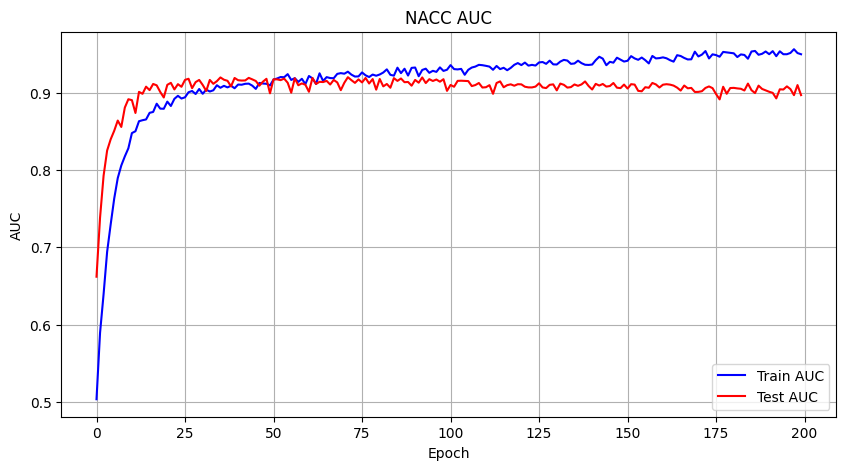

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("NACC AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

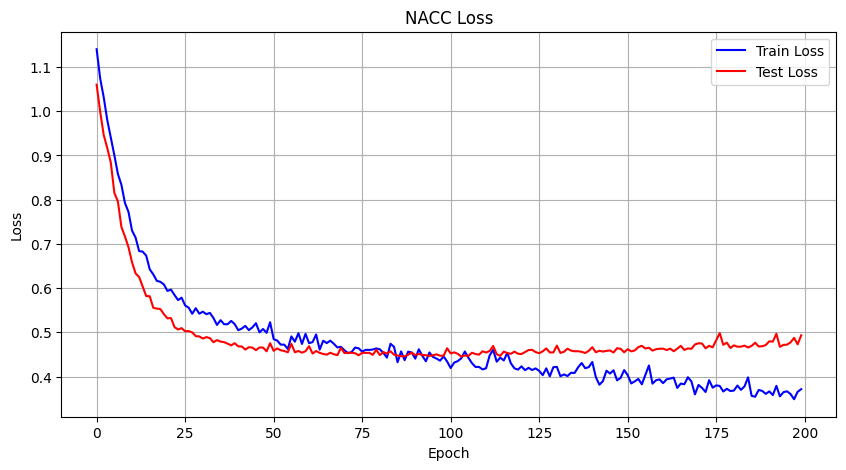

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("NACC Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()